In [1]:
import os, random, warnings, csv as _csv, collections
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
print('Seed set.')

Seed set.


In [4]:
# CONFIG

TRAIN_DATA_ROOT = os.path.expanduser('~/Desktop/george/rocks_spectral_224')
NEW_DATA_ROOT   = os.path.expanduser('~/for_test_data_spectral_224')
OOD_FOLDER      = os.path.join(NEW_DATA_ROOT, 'Dunite-Ecologite_2Rocks_1-83Hz')

RESULTS_DIR = 'results_rock_classifier_multisource_v3'
DIR_TRAIN   = os.path.join(RESULTS_DIR, 'training')
DIR_EVAL    = os.path.join(RESULTS_DIR, 'evaluation')
for d in [RESULTS_DIR, DIR_TRAIN, DIR_EVAL]:
    os.makedirs(d, exist_ok=True)

CAP_PER_SOURCE = 300
TEST_SPLIT     = 0.20
SEEDS          = [7, 42, 123]

ARCH       = 'resnet18'
EPOCHS     = 20
LR         = 1e-4
WD         = 1e-4
BATCH_SIZE = 64

CLASS_NAMES  = ['S10Granite', 'Holstein_Sandstone', 'Leitendorf_Limestone']
SHORT_NAMES  = ['Granite', 'Sandstone', 'Limestone']
CLASS_COLORS = ['#185FA5', '#3B6D11', '#854F0B']
VALID_EXT    = ('.jpg', '.jpeg', '.bmp', '.png')

SOURCES = [
    (os.path.join(TRAIN_DATA_ROOT, 'S10Granite_1-83Hz_Spectral'),          0, 'S10Granite_orig_183'),
    (os.path.join(TRAIN_DATA_ROOT, 'S10Granite_5-10Hz_Spectral'),          0, 'S10Granite_orig_510'),
    (os.path.join(NEW_DATA_ROOT,   'Gneis_1-83Hz'),                        0, 'Gneis_183'),
    (os.path.join(NEW_DATA_ROOT,   'Granite_3SamplesPhilipp_1-83Hz_1'),    0, 'GranPhil_1'),
    (os.path.join(NEW_DATA_ROOT,   'Granite_3SamplesPhilipp_1-83Hz_2'),    0, 'GranPhil_2'),
    (os.path.join(TRAIN_DATA_ROOT, 'Holstein_Sandstone_1-83Hz_Spectral'),  1, 'Holstein_orig_183'),
    (os.path.join(TRAIN_DATA_ROOT, 'Holstein_Sandstone_5-10Hz_Spectral'),  1, 'Holstein_orig_510'),
    (os.path.join(TRAIN_DATA_ROOT, 'Leitendorf_Limestone_1-83Hz_Spectral'),2, 'Leitendorf_orig_183'),
    (os.path.join(TRAIN_DATA_ROOT, 'Leitendorf_Limestone_5-10Hz_Spectral'),2, 'Leitendorf_orig_510'),
    (os.path.join(NEW_DATA_ROOT, 'Limestone_CalcsilicaContaminated_U9_U3_1-83Hz'), 2, 'CalcSil_183'),
    (os.path.join(NEW_DATA_ROOT, 'Limestone_CalcsilicaContaminated_U9_U3_5-10Hz'), 2, 'CalcSil_510'),
]

_saved_files = []
def save_fig(fig, folder, filename, description, dpi=150):
    path = os.path.join(folder, filename)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    _saved_files.append((path, description))
    print(f'[SAVED] {path}')

print('Config ready.')
print(f'  CAP_PER_SOURCE = {CAP_PER_SOURCE}')
print(f'  SEEDS          = {SEEDS}')


Config ready.
  CAP_PER_SOURCE = 300
  SEEDS          = [7, 42, 123]


In [5]:
# LOAD IMAGE POOL PER SOURCE (once) + SPLIT HELPER

def get_images(folder, cap, seed=42):
    if not os.path.isdir(folder):
        print(f'  [MISSING] {folder}')
        return []
    imgs = sorted([str(p) for p in Path(folder).iterdir()
                   if p.suffix.lower() in VALID_EXT])
    random.seed(seed)
    random.shuffle(imgs)
    return imgs[:cap]


source_pool = {}
print(f'Loading sources (cap={CAP_PER_SOURCE})...')
for folder, cls_idx, display in SOURCES:
    imgs = get_images(folder, CAP_PER_SOURCE)
    source_pool[display] = (imgs, cls_idx)
    print(f'  {display:<32} {SHORT_NAMES[cls_idx]:<12} {len(imgs)} images')


def make_split(seed):
    tr_p, tr_l, tr_s, te_p, te_l, te_s = [], [], [], [], [], []
    for display, (imgs, cls_idx) in source_pool.items():
        tr, te = train_test_split(imgs, test_size=TEST_SPLIT,
                                   random_state=seed, shuffle=True)
        tr_p.extend(tr); tr_l.extend([cls_idx]*len(tr)); tr_s.extend([display]*len(tr))
        te_p.extend(te); te_l.extend([cls_idx]*len(te)); te_s.extend([display]*len(te))
    return tr_p, tr_l, tr_s, te_p, te_l, te_s


print(f'\nPool ready. Per seed: {int(CAP_PER_SOURCE*(1-TEST_SPLIT))} train + '
      f'{int(CAP_PER_SOURCE*TEST_SPLIT)} test per source.')


Loading sources (cap=300)...
  S10Granite_orig_183              Granite      300 images
  S10Granite_orig_510              Granite      300 images
  Gneis_183                        Granite      300 images
  GranPhil_1                       Granite      300 images
  GranPhil_2                       Granite      300 images
  Holstein_orig_183                Sandstone    300 images
  Holstein_orig_510                Sandstone    300 images
  Leitendorf_orig_183              Limestone    300 images
  Leitendorf_orig_510              Limestone    300 images
  CalcSil_183                      Limestone    300 images
  CalcSil_510                      Limestone    300 images

Pool ready. Per seed: 240 train + 60 test per source.


In [6]:
# DATASET + TRANSFORMS

train_tf = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class RockDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img), self.labels[idx]


def make_class_weights(labels):
    counts = collections.Counter(labels)
    total  = sum(counts.values())
    return torch.tensor([total / counts[i] for i in range(len(CLASS_NAMES))],
                        dtype=torch.float32).to(device)


print('Dataset and transforms ready.')


Dataset and transforms ready.


[SAVED] results_rock_classifier_multisource_v3/training/DA-01_dataset_composition.png


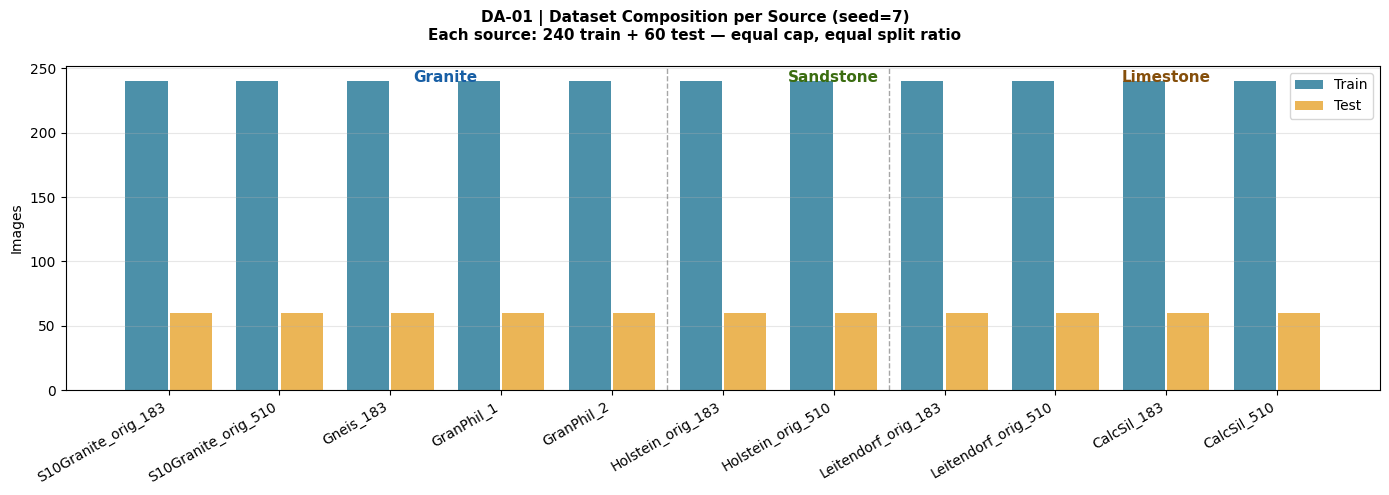

In [7]:
# DA-01  Dataset composition (shown for seed=7, same structure for all seeds)

tr_p, tr_l, tr_s, te_p, te_l, te_s = make_split(SEEDS[0])
source_names = list(source_pool.keys())
tr_counts = collections.Counter(tr_s)
te_counts = collections.Counter(te_s)

x = np.arange(len(source_names))
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('DA-01 | Dataset Composition per Source (seed=7)\n'
             'Each source: 240 train + 60 test — equal cap, equal split ratio',
             fontsize=11, fontweight='bold')
ax.bar(x - 0.2, [tr_counts[s] for s in source_names], 0.38,
       label='Train', color='#2D7D9A', alpha=0.85)
ax.bar(x + 0.2, [te_counts[s] for s in source_names], 0.38,
       label='Test',  color='#E8A838', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(source_names, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Images'); ax.legend(); ax.grid(True, axis='y', alpha=0.3)
n_g = sum(1 for s in SOURCES if s[1]==0 and os.path.isdir(s[0]))
n_s = sum(1 for s in SOURCES if s[1]==1 and os.path.isdir(s[0]))
ax.axvline(n_g - 0.5,     color='gray', ls='--', lw=1.0, alpha=0.7)
ax.axvline(n_g + n_s - 0.5, color='gray', ls='--', lw=1.0, alpha=0.7)
ax.text(n_g/2,                   ax.get_ylim()[1]*0.95, 'Granite',   ha='center', color='#185FA5', fontsize=11, fontweight='bold')
ax.text((n_g*2+n_s)/2,           ax.get_ylim()[1]*0.95, 'Sandstone', ha='center', color='#3B6D11', fontsize=11, fontweight='bold')
ax.text((n_g+n_s+len(source_names))/2, ax.get_ylim()[1]*0.95, 'Limestone', ha='center', color='#854F0B', fontsize=11, fontweight='bold')
plt.tight_layout()
save_fig(fig, DIR_TRAIN, 'DA-01_dataset_composition.png', 'Dataset composition per source')
plt.show()


In [8]:
# MAIN MULTI-SEED LOOP
# 3 seeds x 20 epochs each = 3 independent training runs

def build_model():
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, len(CLASS_NAMES))
    return m.to(device)


def eval_per_source(model, te_paths, te_labels, te_sources):
    results = {}
    for display in source_pool:
        sp = [p for p, s in zip(te_paths, te_sources) if s == display]
        sl = [l for l, s in zip(te_labels, te_sources) if s == display]
        if not sp: continue
        ldr = DataLoader(RockDataset(sp, sl, test_tf), BATCH_SIZE, shuffle=False, num_workers=0)
        correct = total = 0
        with torch.no_grad():
            for Xb, yb in ldr:
                correct += (model(Xb.to(device)).argmax(1)==yb.to(device)).sum().item()
                total   += len(yb)
        results[display] = correct / total * 100
    return results


all_seed_results = {}
all_tr_accs      = {}
all_te_accs      = {}
all_overall      = {}

for seed in SEEDS:
    print(f'\n=== Seed {seed} ===')
    model_path = os.path.join(RESULTS_DIR, f'v3_resnet18_seed{seed}.pth')
    tr_p, tr_l, tr_s, te_p, te_l, te_s = make_split(seed)
    train_ds = RockDataset(tr_p, tr_l, train_tf)
    test_ds  = RockDataset(te_p, te_l, test_tf)
    cw       = make_class_weights(tr_l)
    tr_ldr   = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=0)
    te_ldr   = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0)
    model    = build_model()

    if os.path.exists(model_path):
        print(f'  [SKIP] loading cached weights')
        model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
        model.eval()
        all_tr_accs[seed] = []
        all_te_accs[seed] = []
    else:
        seed_everything(seed)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
        criterion = nn.CrossEntropyLoss(weight=cw)
        use_amp   = device.type == 'cuda'
        scaler    = torch.amp.GradScaler('cuda') if use_amp else None
        tr_a, te_a = [], []
        best_val = 0.0

        for epoch in range(EPOCHS):
            model.train()
            correct = total = 0
            for Xb, yb in tr_ldr:
                Xb, yb = Xb.to(device), yb.to(device)
                optimizer.zero_grad()
                if use_amp:
                    with torch.amp.autocast('cuda'):
                        out = model(Xb); loss = criterion(out, yb)
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer); scaler.update()
                else:
                    out = model(Xb); loss = criterion(out, yb)
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                correct += (out.argmax(1)==yb).sum().item()
                total   += len(yb)
            tr_a.append(correct / total * 100)
            scheduler.step()

            model.eval()
            correct = total = 0
            with torch.no_grad():
                for Xb, yb in te_ldr:
                    correct += (model(Xb.to(device)).argmax(1)==yb.to(device)).sum().item()
                    total   += len(yb)
            val_acc = correct / total * 100
            te_a.append(val_acc)
            if val_acc > best_val:
                best_val = val_acc
                torch.save(model.state_dict(), model_path)
            if (epoch+1) % 5 == 0 or epoch == 0:
                print(f'    Ep {epoch+1:>2}/{EPOCHS}  train={tr_a[-1]:.2f}%  '
                      f'test={val_acc:.2f}%  {"[BEST]" if val_acc==best_val else ""}')

        model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
        model.eval()
        all_tr_accs[seed] = tr_a
        all_te_accs[seed] = te_a
        print(f'  Best: {best_val:.2f}%')

    src_res = eval_per_source(model, te_p, te_l, te_s)
    all_seed_results[seed] = src_res
    all_overall[seed]      = np.mean(list(src_res.values()))
    print(f'  Overall: {all_overall[seed]:.2f}%')
    del model
    torch.cuda.empty_cache()

print('\nAll seeds complete.')



=== Seed 7 ===
    Ep  1/20  train=70.76%  test=76.82%  [BEST]
    Ep  5/20  train=92.23%  test=73.33%  
    Ep 10/20  train=97.31%  test=88.94%  
    Ep 15/20  train=99.09%  test=93.64%  [BEST]
    Ep 20/20  train=99.51%  test=94.09%  
  Best: 94.55%
  Overall: 94.55%

=== Seed 42 ===
    Ep  1/20  train=71.48%  test=82.27%  [BEST]
    Ep  5/20  train=91.52%  test=85.76%  
    Ep 10/20  train=96.82%  test=93.33%  [BEST]
    Ep 15/20  train=99.13%  test=94.70%  
    Ep 20/20  train=99.66%  test=94.55%  
  Best: 95.45%
  Overall: 95.45%

=== Seed 123 ===
    Ep  1/20  train=69.36%  test=73.18%  [BEST]
    Ep  5/20  train=92.84%  test=81.36%  
    Ep 10/20  train=97.05%  test=94.09%  [BEST]
    Ep 15/20  train=99.24%  test=89.55%  
    Ep 20/20  train=99.81%  test=94.39%  
  Best: 94.85%
  Overall: 94.85%

All seeds complete.


[SAVED] results_rock_classifier_multisource_v3/training/TR-01_training_history.png


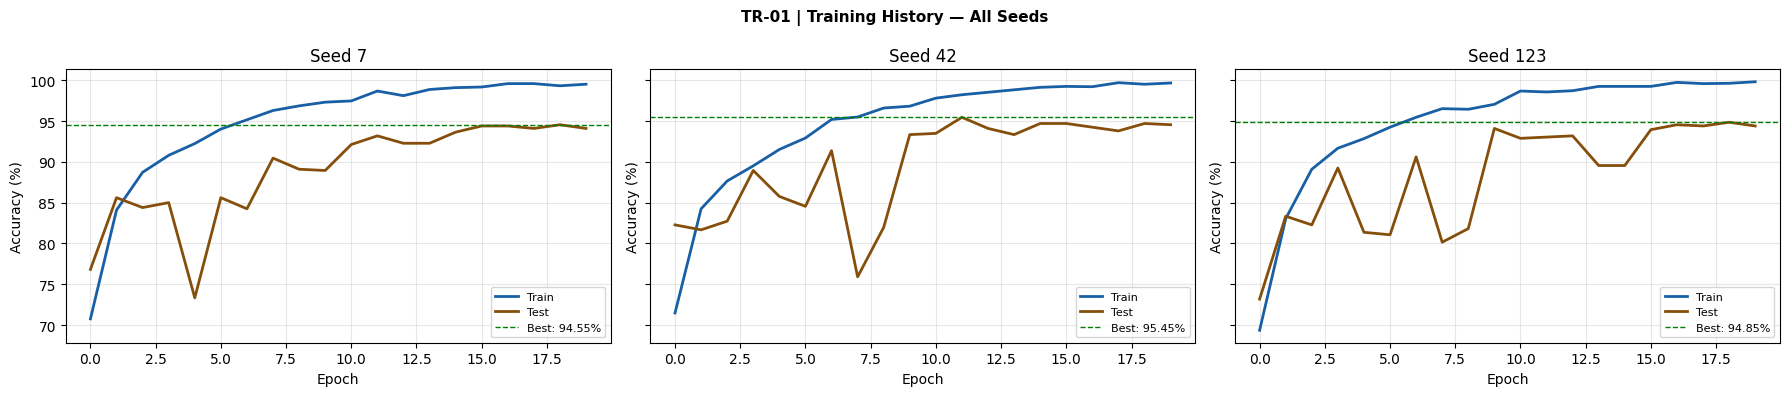

In [9]:
# TR-01  Training history — all seeds
valid_seeds = [s for s in SEEDS if all_tr_accs.get(s)]
if valid_seeds:
    fig, axes = plt.subplots(1, len(valid_seeds),
                              figsize=(6*len(valid_seeds), 4), sharey=True)
    if len(valid_seeds) == 1: axes = [axes]
    fig.suptitle('TR-01 | Training History — All Seeds', fontsize=11, fontweight='bold')
    for ax, seed in zip(axes, valid_seeds):
        best = max(all_te_accs[seed])
        ax.plot(all_tr_accs[seed], label='Train', color='#185FA5', lw=2)
        ax.plot(all_te_accs[seed], label='Test',  color='#854F0B', lw=2)
        ax.axhline(best, color='green', ls='--', lw=1, label=f'Best: {best:.2f}%')
        ax.set_title(f'Seed {seed}'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(fig, DIR_TRAIN, 'TR-01_training_history.png', 'Training history all seeds')
    plt.show()
else:
    print('All seeds loaded from cache.')


In [10]:
# AGGREGATE RESULTS

source_names = list(source_pool.keys())
agg = {}
for display in source_names:
    vals = [all_seed_results[s][display] for s in SEEDS
            if display in all_seed_results.get(s, {})]
    if vals:
        agg[display] = {'mean': float(np.mean(vals)),
                        'std':  float(np.std(vals)),
                        'vals': vals}

overall_mean = float(np.mean([all_overall[s] for s in SEEDS]))
overall_std  = float(np.std( [all_overall[s] for s in SEEDS]))

print(f'Overall accuracy: {overall_mean:.2f}% +/- {overall_std:.2f}%')
print()
print(f'{"Source":<32} {"Class":<12} {"Mean":>7} {"Std":>6}  Values')
print('-' * 80)
for display in source_names:
    if display not in agg: continue
    d   = agg[display]
    cls = source_pool[display][1]
    vals_s = '  '.join(f'{v:.1f}%' for v in d['vals'])
    print(f'  {display:<30} {SHORT_NAMES[cls]:<12} '
          f'{d["mean"]:>6.1f}%  +/-{d["std"]:>4.1f}%  [{vals_s}]')


Overall accuracy: 94.95% +/- 0.38%

Source                           Class           Mean    Std  Values
--------------------------------------------------------------------------------
  S10Granite_orig_183            Granite        98.3%  +/- 1.4%  [96.7%  100.0%  98.3%]
  S10Granite_orig_510            Granite        97.2%  +/- 2.1%  [96.7%  100.0%  95.0%]
  Gneis_183                      Granite        96.7%  +/- 2.7%  [93.3%  100.0%  96.7%]
  GranPhil_1                     Granite        98.9%  +/- 1.6%  [100.0%  100.0%  96.7%]
  GranPhil_2                     Granite        97.8%  +/- 1.6%  [96.7%  100.0%  96.7%]
  Holstein_orig_183              Sandstone      87.2%  +/- 2.8%  [83.3%  88.3%  90.0%]
  Holstein_orig_510              Sandstone      93.9%  +/- 0.8%  [93.3%  93.3%  95.0%]
  Leitendorf_orig_183            Limestone      89.4%  +/- 2.1%  [91.7%  86.7%  90.0%]
  Leitendorf_orig_510            Limestone      98.9%  +/- 0.8%  [98.3%  98.3%  100.0%]
  CalcSil_183           

[SAVED] results_rock_classifier_multisource_v3/evaluation/EV-01_per_source_accuracy_multiseed.png


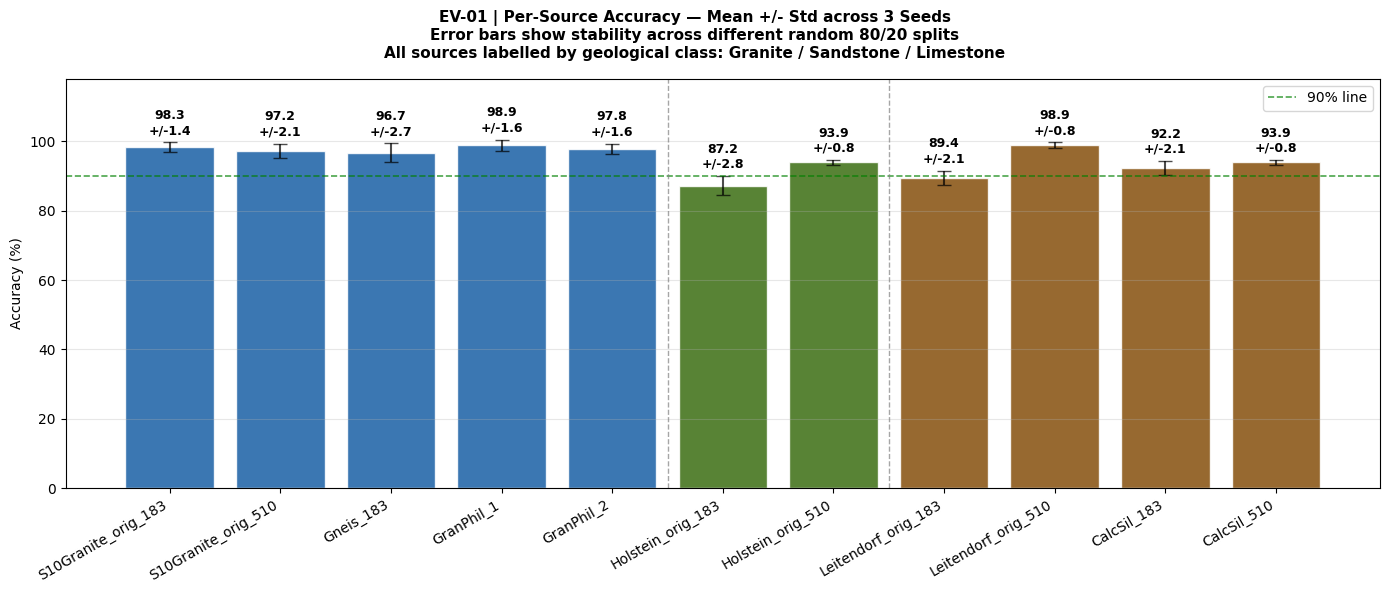

In [11]:
# EV-01  Per-source accuracy — mean +/- std

names  = [d for d in source_names if d in agg]
means  = [agg[d]['mean'] for d in names]
stds   = [agg[d]['std']  for d in names]
colors = [CLASS_COLORS[source_pool[d][1]] for d in names]

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle(
    'EV-01 | Per-Source Accuracy — Mean +/- Std across 3 Seeds\n'
    'Error bars show stability across different random 80/20 splits\n'
    'All sources labelled by geological class: Granite / Sandstone / Limestone',
    fontsize=11, fontweight='bold')

ax.bar(range(len(names)), means, color=colors, alpha=0.85, edgecolor='white',
       yerr=stds, capsize=5,
       error_kw={'elinewidth': 1.5, 'ecolor': 'black', 'alpha': 0.7})
ax.axhline(90, color='green', ls='--', lw=1.2, alpha=0.7, label='90% line')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 118)
ax.legend(); ax.grid(True, axis='y', alpha=0.3)

for i, (mean, std) in enumerate(zip(means, stds)):
    ax.text(i, mean + std + 1.5, f'{mean:.1f}\n+/-{std:.1f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

n_g = sum(1 for s in SOURCES if s[1]==0 and os.path.isdir(s[0]))
n_s = sum(1 for s in SOURCES if s[1]==1 and os.path.isdir(s[0]))
ax.axvline(n_g - 0.5,       color='gray', ls='--', lw=1.0, alpha=0.7)
ax.axvline(n_g + n_s - 0.5, color='gray', ls='--', lw=1.0, alpha=0.7)

plt.tight_layout()
save_fig(fig, DIR_EVAL, 'EV-01_per_source_accuracy_multiseed.png',
    'Per-source accuracy mean +/- std across 3 seeds')
plt.show()


In [12]:
# EV-02  Summary comparison v1/v2/v3

print('=' * 80)
print('MULTI-SOURCE v3 MULTI-SEED RESULTS')
print(f'Seeds: {SEEDS}  CAP_PER_SOURCE: {CAP_PER_SOURCE}  TEST_SPLIT: {TEST_SPLIT}')
print(f'Overall: {overall_mean:.2f}% +/- {overall_std:.2f}%')
print('=' * 80)
print(f'{"Source":<32} {"Class":<12} {"Mean":>7}  {"Std":>6}')
print('-' * 65)
for display in source_names:
    if display not in agg: continue
    d   = agg[display]
    cls = source_pool[display][1]
    print(f'  {display:<30} {SHORT_NAMES[cls]:<12} {d["mean"]:>6.1f}%  +/-{d["std"]:>4.1f}%')
print('=' * 80)
print()
print('Comparison:')
print('  v1 (leaky random split) : inflated')
print('  v2 (folder-based split) : 93.97%  Gneis=75.2%  CalcSil~30%')
print('  v3 single seed          : 96.21%  Gneis=96.7%  CalcSil=91-98%')
print(f'  v3 multi-seed (this)    : {overall_mean:.2f}% +/- {overall_std:.2f}%')


MULTI-SOURCE v3 MULTI-SEED RESULTS
Seeds: [7, 42, 123]  CAP_PER_SOURCE: 300  TEST_SPLIT: 0.2
Overall: 94.95% +/- 0.38%
Source                           Class           Mean     Std
-----------------------------------------------------------------
  S10Granite_orig_183            Granite        98.3%  +/- 1.4%
  S10Granite_orig_510            Granite        97.2%  +/- 2.1%
  Gneis_183                      Granite        96.7%  +/- 2.7%
  GranPhil_1                     Granite        98.9%  +/- 1.6%
  GranPhil_2                     Granite        97.8%  +/- 1.6%
  Holstein_orig_183              Sandstone      87.2%  +/- 2.8%
  Holstein_orig_510              Sandstone      93.9%  +/- 0.8%
  Leitendorf_orig_183            Limestone      89.4%  +/- 2.1%
  Leitendorf_orig_510            Limestone      98.9%  +/- 0.8%
  CalcSil_183                    Limestone      92.2%  +/- 2.1%
  CalcSil_510                    Limestone      93.9%  +/- 0.8%

Comparison:
  v1 (leaky random split) : inflated

In [14]:
# OOD-01  Dunite test

# Load model from last seed for OOD test
last_seed = SEEDS[-1]
model_path = os.path.join(RESULTS_DIR, f'v3_resnet18_seed{last_seed}.pth')
model = build_model()
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.eval()

if os.path.isdir(OOD_FOLDER):
    paths = [str(p) for p in Path(OOD_FOLDER).iterdir()
             if p.suffix.lower() in VALID_EXT]
    ds    = RockDataset(paths, [0]*len(paths), test_tf)
    ldr   = DataLoader(ds, BATCH_SIZE, shuffle=False, num_workers=0)
    probs_all = []
    with torch.no_grad():
        for Xb, _ in ldr:
            probs_all.extend(
                torch.softmax(model(Xb.to(device)), dim=1).cpu().numpy().tolist())
    probs_all   = np.array(probs_all)
    pred_counts = np.bincount(probs_all.argmax(1), minlength=3)
    mean_conf   = np.mean(probs_all.max(1)) * 100
    print(f'Dunite OOD ({len(paths)} images)  mean confidence={mean_conf:.1f}%')
    for ci, name in enumerate(SHORT_NAMES):
        pct = pred_counts[ci] / len(paths) * 100
        print(f'  Predicted as {name}: {pred_counts[ci]} ({pct:.1f}%)')
else:
    print(f'[SKIP] OOD folder not found: {OOD_FOLDER}')

Dunite OOD (500 images)  mean confidence=92.9%
  Predicted as Granite: 84 (16.8%)
  Predicted as Sandstone: 12 (2.4%)
  Predicted as Limestone: 404 (80.8%)


In [15]:
# RESULTS INDEX
index_path = os.path.join(RESULTS_DIR, 'RESULTS_INDEX.txt')
with open(index_path, 'w') as f:
    f.write('RESULTS INDEX - rock_classifier_multisource_v3 (multi-seed)\n')
    f.write('=' * 80 + '\n')
    f.write(f'CAP_PER_SOURCE={CAP_PER_SOURCE}  TEST_SPLIT={TEST_SPLIT}\n')
    f.write(f'SEEDS={SEEDS}  EPOCHS={EPOCHS}  LR={LR}  WD={WD}  BATCH={BATCH_SIZE}\n\n')
    f.write(f'Overall accuracy: {overall_mean:.2f}% +/- {overall_std:.2f}%\n\n')
    f.write('PER-SOURCE ACCURACY (mean +/- std)\n' + '-'*80 + '\n')
    for display in source_names:
        if display not in agg: continue
        d   = agg[display]
        cls = source_pool[display][1]
        f.write(f'  {display:<32} {SHORT_NAMES[cls]:<12} '
                f'{d["mean"]:.2f}% +/- {d["std"]:.2f}%\n')
    f.write('\nFILES\n' + '-'*80 + '\n')
    for path, desc in _saved_files:
        f.write(f'  {os.path.basename(path)}\n    {desc}\n\n')
_saved_files.append((index_path, 'Results index'))
print(f'[SAVED] {index_path}')


[SAVED] results_rock_classifier_multisource_v3/RESULTS_INDEX.txt
